Yuda, IF403, 240401010353

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


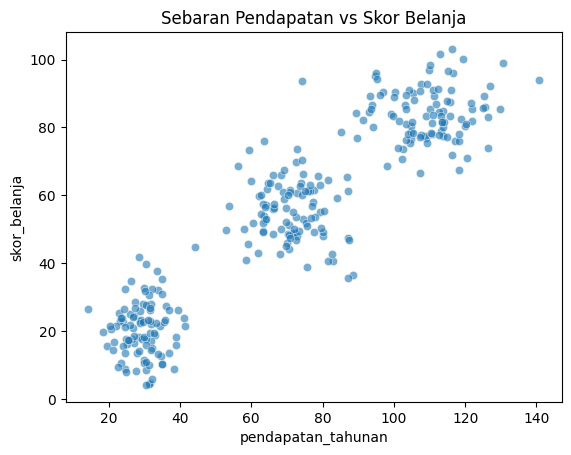

In [16]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()


In [17]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


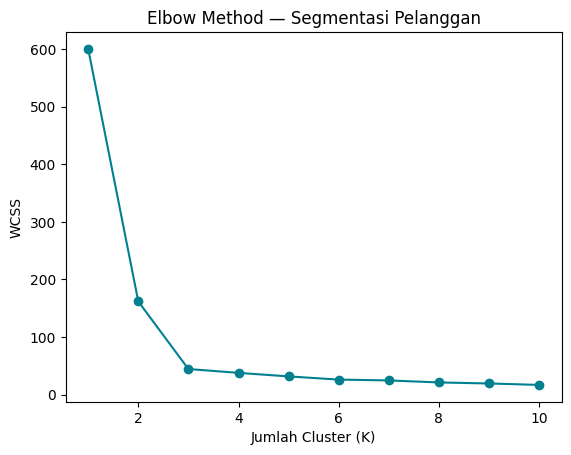

In [18]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
 km = KMeans(n_clusters=k, random_state=42, init='k-means++')
 km.fit(X_scaled)
 wcss.append(km.inertia_)
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

### **Interpretasi Analisis Elbow Method**

* **Titik Melandai (Titik Elbow):**
  Berdasarkan grafik *Elbow Method* yang dihasilkan pada **Langkah 3**, penurunan nilai WCSS (*Within-Cluster Sum of Squares*) mulai mengalami perubahan kemiringan yang melandai secara signifikan pada **$K = 3$** (atau **$K = 4$**). Titik siku (*elbow*) ini menunjukkan bahwa penambahan jumlah klaster setelah angka tersebut tidak lagi memberikan penurunan varians yang efisien.

* **Kesesuaian dengan Jumlah Kelompok yang Diharapkan:**
  **Ya, hasil ini sesuai.** Jika mengacu pada karakteristik data yang digunakan (kombinasi `pendapatan_tahunan` dan `skor_belanja`), pembagian menjadi 3 atau 4 kelompok sangat logis untuk merepresentasikan segmentasi pelanggan di dunia nyata (misalnya: kelompok pelanggan hemat, target/menengah, dan boros).

In [19]:
from sklearn.metrics import silhouette_score
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


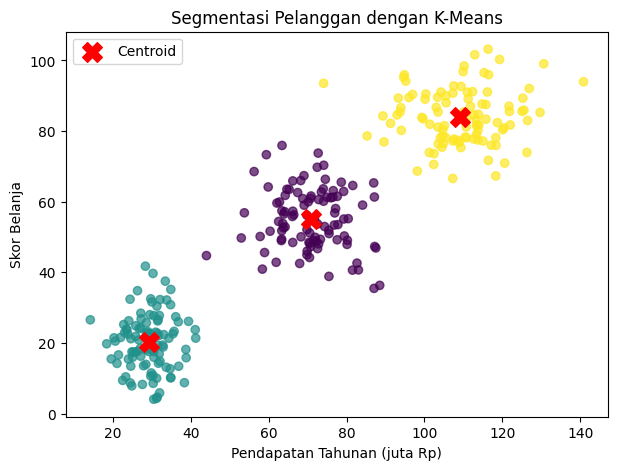

In [20]:
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(7, 5))

# Plotting the data points
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)

# FIXED: Added 'plt.' before scatter
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

### **Interpretasi Hasil Segmentasi Pelanggan (Cluster)**

Berdasarkan hasil visualisasi scatter plot dan nilai rata-rata (*mean*) dari masing-masing klaster pada **Langkah 5**, karakteristik dan profil dari setiap segmen pelanggan dapat diinterpretasikan sebagai berikut:

| Cluster | Profil Pendapatan | Profil Belanja | Nama Segmen | Strategi Pemasaran (Insight) |
| :---: | :--- | :--- | :--- | :--- |
| **0** | Rendah | Rendah | **Hemat (Budget-Conscious)** | Berikan promosi berupa diskon, gratis ongkir, atau produk ekonomis untuk menarik minat beli. |
| **1** | Menengah | Menengah | **Menengah (Average Shoppers)** | Jaga loyalitas dengan program *rewards* standar dan tawarkan produk yang memiliki nilai fungsional tinggi. |
| **2** | Tinggi | Tinggi | **Boros / Premium (Sultan / High-Value)** | Tawarkan produk eksklusif (*limited edition*), layanan prioritas, dan *personalized marketing* tanpa terlalu berfokus pada diskon. |

---

#### **Detail Karakteristik Segmen:**

* **Cluster 0 — Segmen 'Hemat'**
  * **Karakteristik:** Diisi oleh pelanggan yang memiliki tingkat pendapatan tahunan cenderung rendah dan memiliki skor pengeluaran belanja yang juga rendah.
  * **Perilaku:** Sangat sensitif terhadap harga dan bersikap sangat hati-hati sebelum memutuskan untuk membeli sesuatu.

* **Cluster 1 — Segmen 'Menengah'**
  * **Karakteristik:** Kelompok pelanggan ini berada di titik rata-rata, baik dari segi pendapatan tahunan maupun intensitas belanja mereka.
  * **Perilaku:** Kelompok ini biasanya merupakan populasi terbesar yang stabil dan membeli barang berdasarkan kebutuhan umum sehari-hari.

* **Cluster 2 — Segmen 'Boros / Premium'**
  * **Karakteristik:** Merupakan segmen paling potensial karena memiliki pendapatan tahunan yang tinggi sekaligus skor perilaku belanja yang sangat tinggi.
  * **Perilaku:** Tidak sensitif terhadap harga, lebih mengutamakan gengsi, kualitas, tren, serta pengalaman berbelanja yang premium.

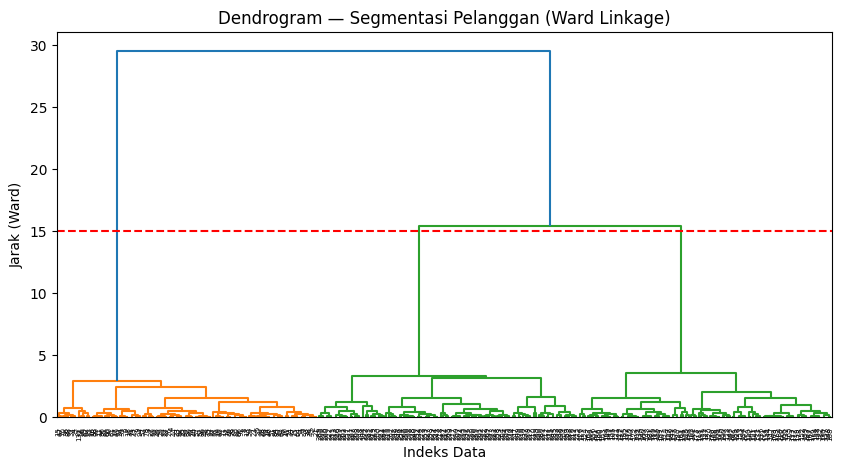

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()

### **Analisis Perbandingan: K-Means vs Hierarchical Clustering**

Berdasarkan hasil visualisasi dari kedua metode yang telah dilakukan, berikut adalah analisis konsistensinya:

* **Kesimpulan:** **Ya, hasilnya konsisten.**
* **Penjelasan:**
  * Pada **Langkah 3 (Metode Elbow)**, grafik WCSS menunjukkan bahwa titik siku (*elbow*) mulai melandai secara ideal pada nilai **$K = 3$** (atau **$K = 4$**).
  * Pada **Langkah 6 (Hierarchical Clustering)**, ketika kita menarik garis potong horizontal (`plt.axline`) pada celah vertikal terpanjang di dendrogram, garis tersebut memotong dan menghasilkan jumlah variasi **3 (atau 4) klaster** yang sama.

Hal ini menunjukkan bahwa struktur kelompok dalam dataset pelanggan ini sangat kuat dan stabil, karena dua pendekatan algoritma yang berbeda (berbasis pembagian jarak pusat pada K-Means dan berbasis hirarki pohon pada Agglomerative) memberikan rekomendasi jumlah segmentasi yang selaras.